First 5 rows:
  Order ID  Amount  Profit  Quantity     Category      Sub-Category
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases
1  B-25601    66.0   -12.0         5     Clothing             Stole
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games
4  B-25602   168.0  -111.0         2  Electronics            Phones

Dataset Shape: (1500, 6)

Columns:
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

Profit Class Distribution:
Profit_Class
1    950
0    550
Name: count, dtype: int64

Training samples: 1200
Testing samples: 300

Decision Tree model trained successfully!

Decision Tree Accuracy: 67.33 %

Classification Report:
                 precision    recall  f1-score   support

Negative Profit       0.70      0.19      0.30       110
Positive Profit       0.67      0.95      0.79       190

       accuracy                           0.67       300
      mac

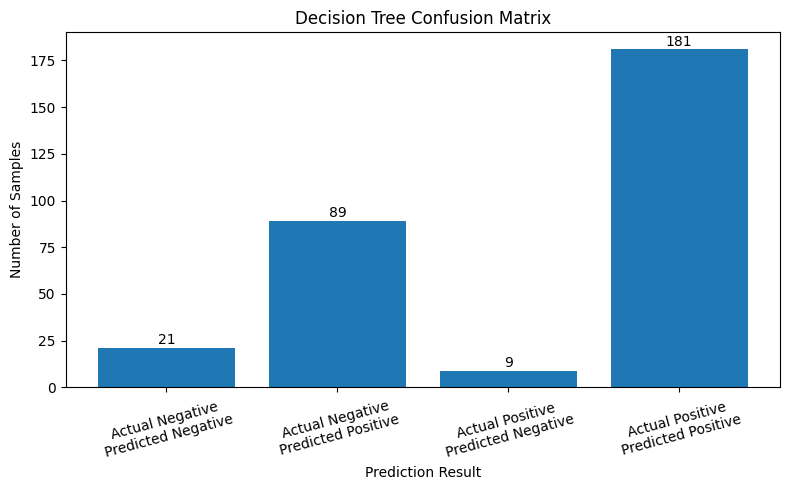

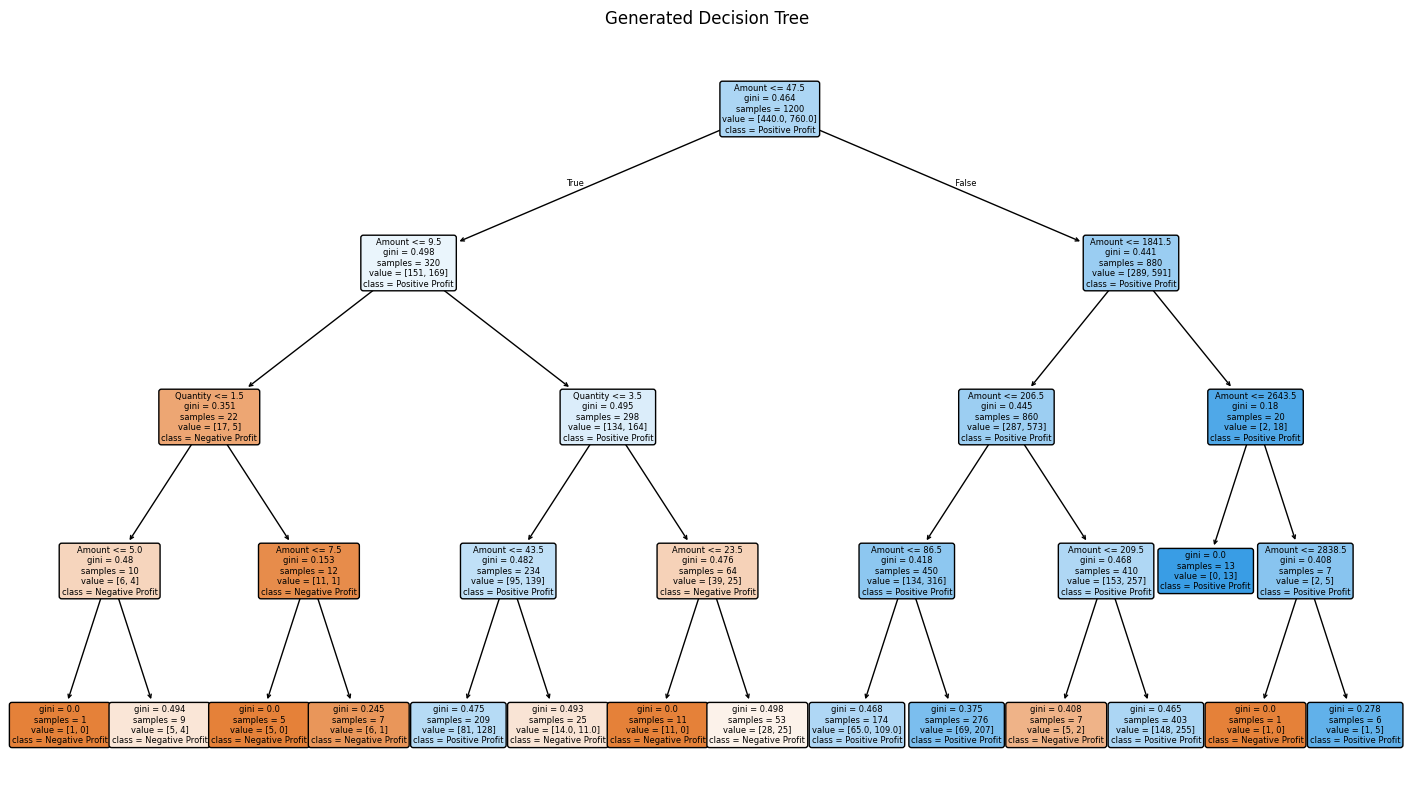

In [7]:
# PRACTICAL 1: DECISION TREE LEARNING
# Dataset: Order Details.csv

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset

df = pd.read_csv("Order Details.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# 2. Create Binary Target Variable

# Profit > 0 = Positive Profit (1)
# Profit <= 0 = Negative Profit (0)

df["Profit_Class"] = (df["Profit"] > 0).astype(int)

print("\nProfit Class Distribution:")
print(df["Profit_Class"].value_counts())

# 3. Select Features and Target

X = df[["Amount", "Quantity"]]
y = df["Profit_Class"]

# 4. Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# 5. Create and Train Decision Tree

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("\nDecision Tree model trained successfully!")

y_pred = dt_model.predict(X_test)

# 7. Evaluate Model

accuracy = accuracy_score(y_test, y_pred)

print("\nDecision Tree Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative Profit", "Positive Profit"]
))

# 8. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

labels = [
    "Actual Negative\nPredicted Negative",
    "Actual Negative\nPredicted Positive",
    "Actual Positive\nPredicted Negative",
    "Actual Positive\nPredicted Positive"
]

values = [
    cm[0, 0],
    cm[0, 1],
    cm[1, 0],
    cm[1, 1]
]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.xlabel("Prediction Result")
plt.ylabel("Number of Samples")
plt.title("Decision Tree Confusion Matrix")

# Show values on top of bars
for i, value in enumerate(values):
    plt.text(i, value + 2, str(value), ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 9. Visualize Decision Tree

plt.figure(figsize=(18, 10))

plot_tree(
    dt_model,
    feature_names=["Amount", "Quantity"],
    class_names=["Negative Profit", "Positive Profit"],
    filled=True,
    rounded=True
)

plt.title("Generated Decision Tree")
plt.show()